# Hyperparameter Optimization (HPO)

## Objective:
In this lab, you will learn to use [Optuna](https://optuna.org/) to fine-tune a [CatBoost](https://catboost.ai/docs/en/concepts/python-quickstart) model on the [Covertype Dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_covtype.html). The objective is to maximize classification accuracy by finding the best hyperparameter combination for this multiclass classification problem.

## 1. Installing Necessary Packages

To get started, install the required Python packages by running the following command in your terminal or command prompt:

```bash
pip install optuna catboost pandas scikit-learn optuna-dashboard seaborn matplotlib
```

What’s Installed:
- Optuna: For hyperparameter optimization.
- CatBoost: The gradient boosting library we’ll tune.
- Pandas: For data manipulation.
- Scikit-learn: For dataset loading and evaluation metrics.
- Optuna-dashboard: For real-time monitoring of optimization.
- Seaborn & Matplotlib: For data visualizations.

## 2. Loading the Covertype Dataset
The Covertype dataset is a multiclass classification task with 54 features, 7 classes, and over 500,000 samples. We’ll load it directly using Scikit-learn’s `fetch_covtype` function.

In [2]:
from sklearn.datasets import fetch_covtype
import pandas as pd

# Load the dataset
covtype = fetch_covtype(as_frame=True)  # Returns a DataFrame
X = covtype.data  # Features
y = covtype.target - 1  # Target (adjusted to 0-6 for zero-based indexing)

Why Covertype?
- Multiclass Complexity: Predicts 7 forest cover types.
- Mixed Features: Includes both numerical and categorical (binary) features, perfect for CatBoost.
- Large Scale: Tests model performance on a substantial dataset.

To make computations faster, we'll take into account only 20k samples.

In [3]:
sample_size = 20000
# Ensure we get a balanced sample across all classes
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=sample_size, random_state=42, stratify=y
)
X = X_sample
y = y_sample

## 3. Visualizing the Dataset
Visualizations help us understand the data before modeling. Below are three useful plots:

### Class Distribution
Examine the balance of classes in the target variable.

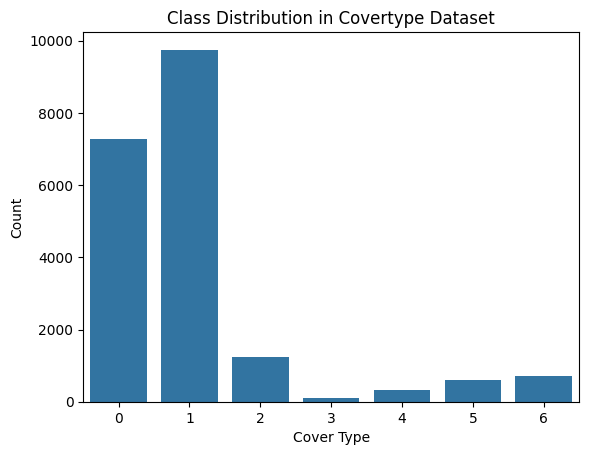

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title('Class Distribution in Covertype Dataset')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

### Feature Correlation Heatmap
Check correlations among the first 10 features.

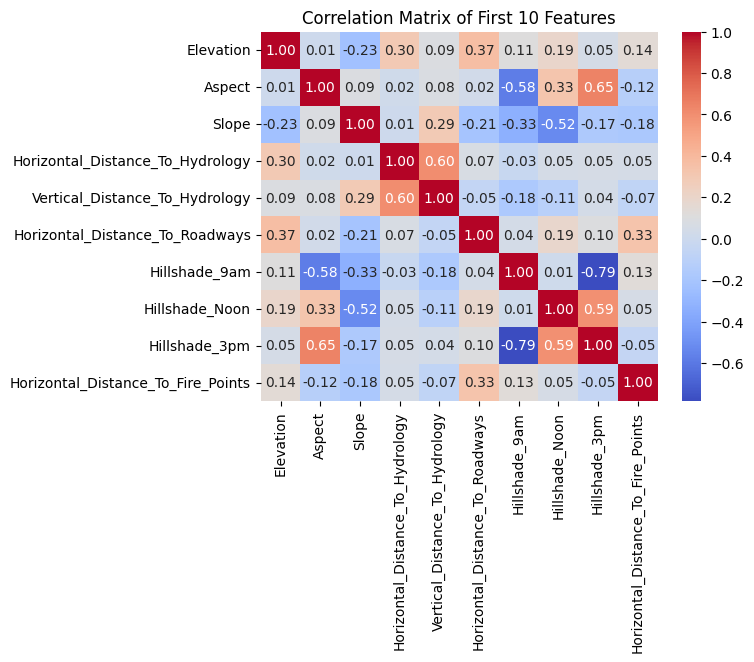

In [5]:
# Select first 10 features for simplicity
subset = X.iloc[:, :10]

# Compute correlation matrix
corr = subset.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of First 10 Features')
plt.show()


### Pairplot for Selected Features
Visualize relationships between the first 3 features and class separation.

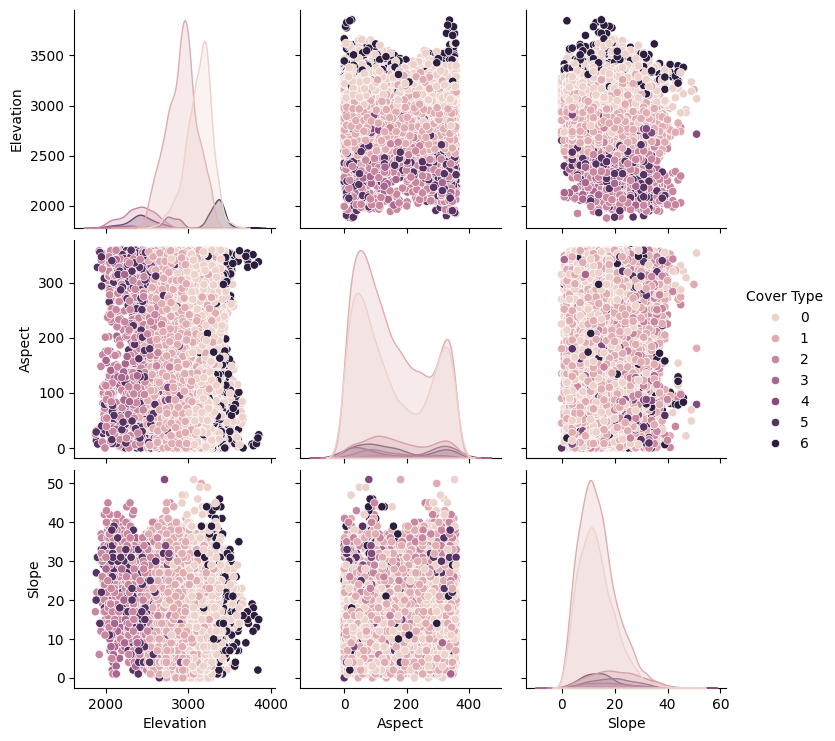

In [6]:
# Combine features and target for a sample
sample = X.iloc[:, :3].copy()  # First 3 features
sample['Cover Type'] = y

sns.pairplot(sample, hue='Cover Type', diag_kind='kde')
plt.show()

## 4. Train and evaluate CatBoost with default settings

Before performing hyperparameter optimization, it’s important to establish a baseline model using CatBoost with default settings. This helps us gauge how much improvement is achieved through tuning.


In [7]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the dataset into training, validation and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Initialize the CatBoost model with default settings
model = CatBoostClassifier(verbose=0, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Accuracy: 83.43%


Confusion matrices are great for understanding the model's performance on a per-class basis. They provide detailed insight into which classes are being confused with each other, allowing you to identify weaknesses in the model’s predictions.

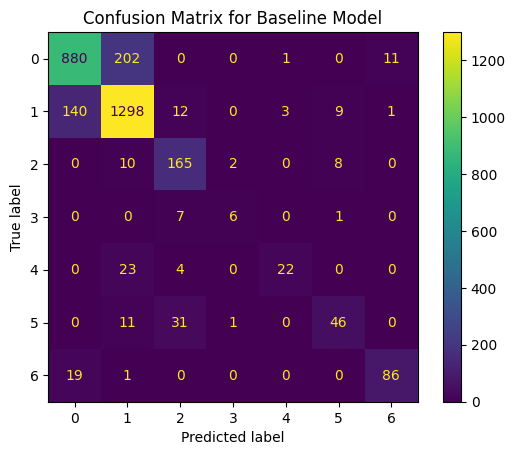

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix for Baseline Model')
plt.show()

## 5. Implementing Hyperparameter Tuning with Optuna
The objective function drives the optimization:
- Takes a trial object from Optuna.
- Suggests hyperparameter values.
- Trains a CatBoost model.
- Evaluates accuracy on the validation set.
- Returns the score (accuracy).

This [notebook](https://github.com/optuna/optuna-examples/blob/main/quickstart.ipynb) provides a useful example of implementing Optuna, although it employs cross-validation (CV) rather than a train/validation split. Additionally, the CatBoost documentation [page](https://catboost.ai/docs/en/concepts/parameter-tuning) offers comprehensive guidance on parameter tuning.

In [9]:
import optuna
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        # TODO: Investigate CatBoost docs and add more hyperparameters
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_index, valid_index in skf.split(X, y):
        X_train_fold, X_valid_fold = X.iloc[train_index], X.iloc[valid_index]
        y_train_fold, y_valid_fold = y.iloc[train_index], y.iloc[valid_index]

        # TODO: 
        # 1. Train CatBoost using params
        model = CatBoostClassifier(**params, verbose=0, random_state=42)
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_valid_fold)

        score = accuracy_score(y_valid_fold, y_pred)
        scores.append(score)
        # 2. Return validation accuracy score as result

    return np.mean(scores)
    # Area for improvement: use Cross-Validation instead of a single train/val split.

C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set up and run the Optuna study:


In [10]:
# Create the study
study_name = 'catboost_optimization'
storage_name = 'sqlite:///example.db' 
study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction='maximize',
    load_if_exists=True
)
study.optimize(objective, n_trials=20)  # Run 20 trials

[I 2026-04-20 10:12:48,622] A new study created in RDB with name: catboost_optimization
[I 2026-04-20 10:15:31,780] Trial 0 finished with value: 0.8308500000000001 and parameters: {'iterations': 750, 'learning_rate': 0.07361758211748626, 'depth': 7}. Best is trial 0 with value: 0.8308500000000001.
[I 2026-04-20 10:29:00,043] Trial 1 finished with value: 0.84055 and parameters: {'iterations': 696, 'learning_rate': 0.049532548782528274, 'depth': 10}. Best is trial 1 with value: 0.84055.
[I 2026-04-20 10:37:57,923] Trial 2 finished with value: 0.8484 and parameters: {'iterations': 860, 'learning_rate': 0.09132883888964162, 'depth': 9}. Best is trial 2 with value: 0.8484.
[I 2026-04-20 10:38:11,245] Trial 3 finished with value: 0.76435 and parameters: {'iterations': 277, 'learning_rate': 0.10420365942698448, 'depth': 4}. Best is trial 2 with value: 0.8484.
[I 2026-04-20 10:39:15,932] Trial 4 finished with value: 0.7654000000000001 and parameters: {'iterations': 973, 'learning_rate': 0.0180

## 6. Setting up Optuna Dashboard
Optuna offers a dashboard to monitor optimization in real-time. Launch it with:
optuna-dashboard sqlite:///example.db

Monitor trials at http://localhost:8080. Discuss results. Which features are most important?


1. Iterations  (0.68)
With a score of 0.68 (or 68%), the number of iterations was by far the most critical setting during this optimization. Finding the right stopping point for the algorithm had the biggest impact on whether model's accuracy went up or down.
2. Depth  (0.17)
The depth of the trees contributed to about 17% of the impact on the model's performance. It played a noticeable role, but significantly less than just getting the total number of trees right.
3. learning_rate (0.15)
The learning rate was the least influential of the three in this specific study, contributing about 15%. Interestingly, depth and learning_rate had a very similar level of impact on your model's success.



## 7. Post-Optimization Steps: Analyzing Results and Final Evaluation

After the Optuna study completes, we need to analyze the results, train a final model using the best hyperparameters found, and evaluate its performance on the unseen test set.


In [11]:
# Retrieve the best trial from the study
best_trial = study.best_trial

print(f"Best Trial Number: {best_trial.number}")
print(f"Best Validation Accuracy: {best_trial.value:.4f}")
print("Best Hyperparameters Found:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best Trial Number: 12
Best Validation Accuracy: 0.8504
Best Hyperparameters Found:
  iterations: 492
  learning_rate: 0.22120467988750536
  depth: 10


> Note: Review the best hyperparameters found. Do they make sense? Are any parameters hitting the boundaries of their search space (e.g., iterations consistently at 1000)? If so, you might consider expanding the search space in a future run. The "Best Validation Accuracy" is the score Optuna maximized using the validation set within the objective function.




1. Do they make sense? 
Yes. A moderate number of trees (492) paired with a relatively fast learning rate (0.22) and highly complex trees (depth 10) is a logical combination that achieved a strong 85% accuracy.

2. Hitting boundaries? 
Yes, specifically depth. It hit the absolute maximum limit (10) of your defined search space (4-10). The other parameters (iterations and learning_rate) stopped safely in the middle of their ranges.

Now, we train a new CatBoost model using the best hyperparameters found by Optuna. Crucially, we train this model on the combination of the original training data and validation data. This allows the final model to learn from more data than any single model trained during the optimization trials.


In [12]:
best_params = best_trial.params

# --- IMPORTANT: Combine Training and Validation Data ---
# Create the full training dataset (train + validation) for the final model
X_train_full = pd.concat([X_train, X_valid], ignore_index=True)
y_train_full = pd.concat([y_train, y_valid], ignore_index=True)

final_params = best_params.copy()
final_params['random_state'] = 42

final_model = CatBoostClassifier(**final_params)
final_model.fit(X_train_full, y_train_full)

0:	learn: 1.4480458	total: 293ms	remaining: 2m 23s
1:	learn: 1.2344448	total: 501ms	remaining: 2m 2s
2:	learn: 1.0855759	total: 745ms	remaining: 2m 1s
3:	learn: 0.9855359	total: 991ms	remaining: 2m
4:	learn: 0.9037364	total: 1.2s	remaining: 1m 56s
5:	learn: 0.8389897	total: 1.47s	remaining: 1m 59s
6:	learn: 0.7897143	total: 1.7s	remaining: 1m 58s
7:	learn: 0.7511470	total: 1.92s	remaining: 1m 56s
8:	learn: 0.7201556	total: 2.15s	remaining: 1m 55s
9:	learn: 0.6927542	total: 2.42s	remaining: 1m 56s
10:	learn: 0.6696905	total: 2.67s	remaining: 1m 56s
11:	learn: 0.6509130	total: 2.89s	remaining: 1m 55s
12:	learn: 0.6324767	total: 3.1s	remaining: 1m 54s
13:	learn: 0.6158939	total: 3.33s	remaining: 1m 53s
14:	learn: 0.6033642	total: 3.58s	remaining: 1m 53s
15:	learn: 0.5911523	total: 3.82s	remaining: 1m 53s
16:	learn: 0.5812021	total: 4.04s	remaining: 1m 52s
17:	learn: 0.5699775	total: 4.25s	remaining: 1m 51s
18:	learn: 0.5599788	total: 4.49s	remaining: 1m 51s
19:	learn: 0.5524779	total: 4.6

CatBoostClassifier(depth=10, iterations=492, learning_rate=0.22120467988750536, random_state=42)


This is the moment of truth! We evaluate our optimized `final_model` on the completely unseen X_test and y_test to get an unbiased estimate of its generalization performance. We then compare this to the baseline model's performance on the same test set.



--- Performance Comparison ---
Baseline Accuracy (on Test Set): 83.43%
Optimized Accuracy (on Test Set): 84.67%
Improvement due to HPO: 1.23%
Confusion Matrix for Final Optimized Model (on Test Set):


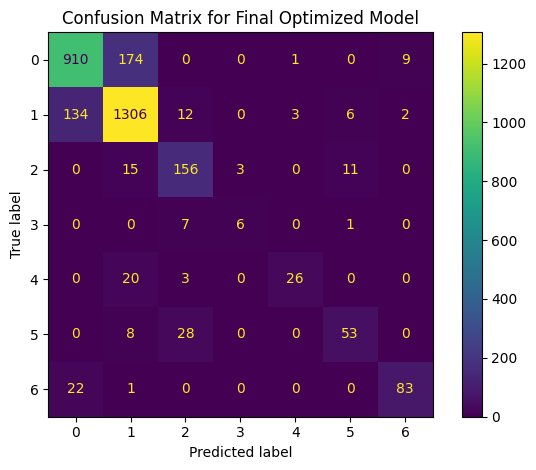

In [13]:
y_pred_test = final_model.predict(X_test)

# Calculate final accuracy
final_accuracy = accuracy_score(y_test, y_pred_test)

print("--- Performance Comparison ---")
# Assuming baseline_accuracy variable holds the score from Step 5
print(f"Baseline Accuracy (on Test Set): {baseline_accuracy * 100:.2f}%")
print(f"Optimized Accuracy (on Test Set): {final_accuracy * 100:.2f}%")
improvement = final_accuracy - baseline_accuracy
print(f"Improvement due to HPO: {improvement * 100:.2f}%")

print("Confusion Matrix for Final Optimized Model (on Test Set):")
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title('Confusion Matrix for Final Optimized Model')
plt.tight_layout()
plt.show()

Finally, let's examine which features the optimized CatBoost model found most important for making predictions.


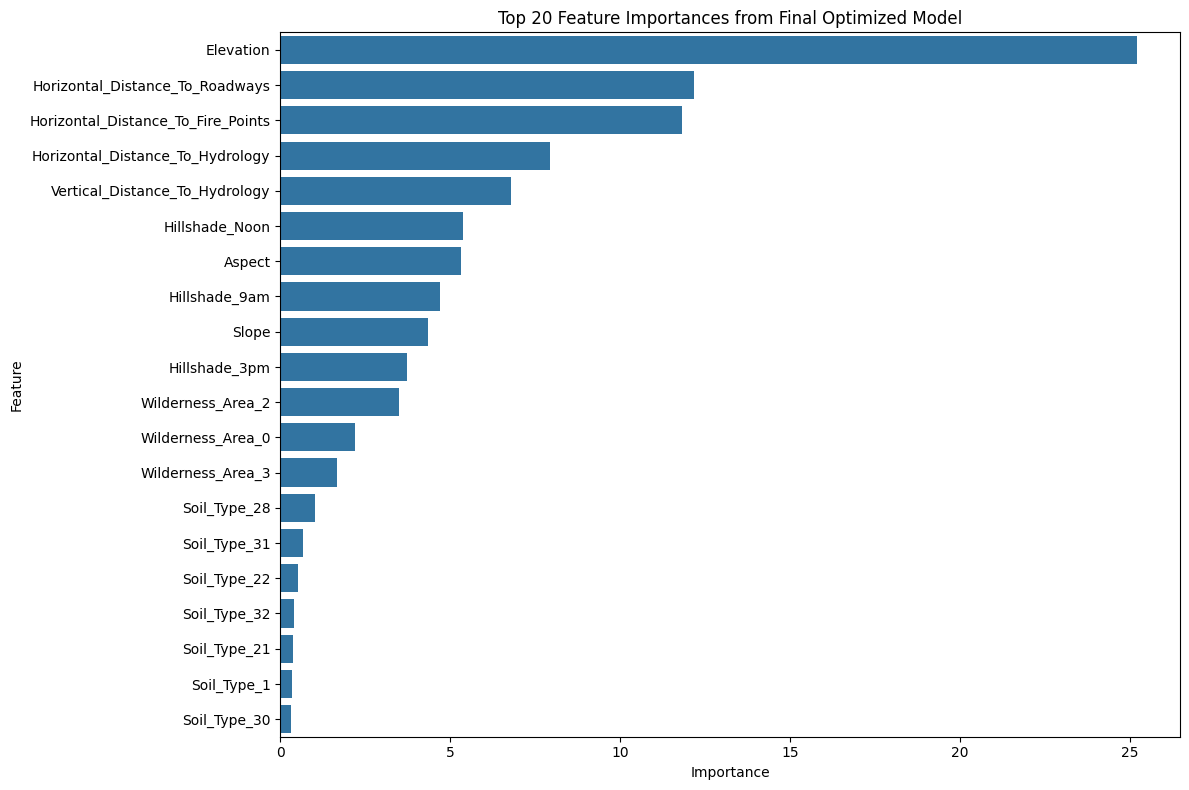

In [14]:
importances = final_model.get_feature_importance()
feature_names = X_train_full.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances (e.g., top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20)) # Plot top 20
plt.title('Top 20 Feature Importances from Final Optimized Model')
plt.tight_layout()
plt.show()

Elevation is by far the most dominant factor, holding more than double the predictive weight of the next closest feature.

Distances to infrastructure (roadways, fire points) and water (hydrology) form the second most important group of features.

Soil types are largely irrelevant: Individually, the specific soil types contribute almost nothing to the model's final decisions.